# Part 1: Python Basics - Code Time Value of Money and Capital Budgeting 

## Advanced TVM and Capital Budgeting with Numpy Financial Functions

__NEW: You need to download and install the package numpy-financial first with the command:__

pip install numpy-financial

__NEW: You can then import numpy-financial with the code:__

In [1]:
import numpy_financial as npf

__NEW__:

np.npv,  np.irr,  np.fv,  np.pmt,  np.nper,  np.pv,  np.ppmt,   np.ipmt __turned into__ <br>
npf.npv, npf.irr, npf.fv, npf.pmt, npf.nper, npf.pv, npf.ppmt,  npf.ipmt !!!

### Evaluating Investments with npf.npv() and npf.irr()

In [5]:
import numpy as np
import numpy_financial as npf # NEW!!!!

The XYZ Company evaluates to buy a new machine that will increase profits/cashflows for XYZ by 
- 20 USD in t1, 
- 50 USD in t2, 
- 70 USD in t3, 
- 100 USD in t4 and 
- 50 USD in t5.<br>

The machine costs 200 USD (Investment in to). Calculate the __Project´s NPV__ and __IRR__ and evaluate whether XYZ should pursue the project. <br> XYZs required rate of return is 6%.

In [6]:
cf = np.array([-200, 20, 50, 70, 100, 50])
r = 0.06

In [7]:
#np.npv(r, cf) # removed from numpy version 1.2

In [8]:
npf.npv(rate = r, values = cf) # new: npf.npv instead of np.npv

38.71337130837991

In [9]:
npf.npv(rate = r, values = cf) > 0 

True

In [10]:
npf.irr(values = cf)

0.1190693988331708

In [11]:
print(f"The IRR (Internal Required Return) of the project is: %{npf.irr(values=cf)*100:.2f}.")
print(f"Since IRR (%{npf.irr(values=cf)*100:.2f}) > Rate (%6), then we accept the project.")

The IRR (Internal Required Return) of the project is: %11.91.
Since IRR (%11.91) > Rate (%6), then we accept the project.


The XYZ Company issued a 10Y Senior Unsecured Bond one year ago with a Coupon Rate of 5.0% (annual payments in arrears). Today´s Bond Price is 107.5 (per 100 par Value). Calculate the Bond´s __current YTM__.

In [12]:
coupon_rate = 0.05

In [13]:
cf_bond = [5] * 9
cf_bond

[5, 5, 5, 5, 5, 5, 5, 5, 5]

In [14]:
cf_bond[-1] = cf_bond[-1] + 100
cf_bond

[5, 5, 5, 5, 5, 5, 5, 5, 105]

In [15]:
cf_bond.insert(0, -107.5)
cf_bond

[-107.5, 5, 5, 5, 5, 5, 5, 5, 5, 105]

In [16]:
npf.irr(cf_bond)

0.039916847253554044

In [17]:
print(f"The current YTM is (%{npf.irr(cf_bond)*100:.2f}) which is < the courpon rate (%{coupon_rate*100}). So we buy the bond.")

The current YTM is (%3.99) which is < the courpon rate (%5.0). So we buy the bond.


### Evaluating Annuities with npf.fv() - funding phase

In [18]:
import numpy as np
import numpy_financial as npf

In [19]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

You save 2,000 USD p.a. for the next 25 Years (payment at year end) and get an interest rate of 3% p.a. on your savings. <br>
What is the value of your savings account (__FV__) in 25 years?

In [20]:
n = 25
r = 0.03
cf = 2000
PV = 0

# FV = ?

In [21]:
FV_manual = np.array([])
for i in range(1,n+1):
    PV = PV*(1+r) + cf
    FV_manual = np.append(FV_manual, PV)
FV_manual

array([ 2000.        ,  4060.        ,  6181.8       ,  8367.254     ,
       10618.27162   , 12936.8197686 , 15324.92436166, 17784.67209251,
       20318.21225528, 22927.75862294, 25615.59138163, 28384.05912308,
       31235.58089677, 34172.64832367, 37197.82777338, 40313.76260659,
       43523.17548478, 46828.87074933, 50233.73687181, 53740.74897796,
       57352.9714473 , 61073.56059072, 64905.76740844, 68852.94043069,
       72918.52864361])

In [22]:
FV_manual.argmax() , FV_manual[FV_manual.argmax()]

(24, 72918.52864361432)

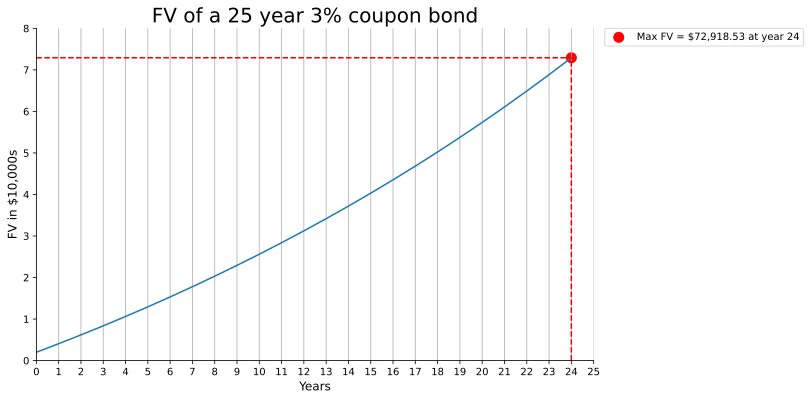

In [23]:
plt.figure(figsize=(10,6))
plt.plot(FV_manual/(10**4)) 
plt.title("FV of a 25 year 3% coupon bond" , fontsize=20)
plt.xlabel("Years", fontsize = 12)
plt.ylabel("FV in $10,000s", fontsize = 12)



plt.plot([FV_manual.argmax(),FV_manual.argmax()] , 
         [0 , FV_manual[FV_manual.argmax()]/(10**4)] , 
         ls = "--", 
         color = "red", 
         markersize = 10)
plt.plot([0,FV_manual.argmax()] , 
         [FV_manual[FV_manual.argmax()]/(10**4) , FV_manual[FV_manual.argmax()]/(10**4)] , 
         ls = "--", 
         color = "red", 
         markersize = 10)
plt.scatter(FV_manual.argmax() , 
            FV_manual[FV_manual.argmax()]/(10**4) , 
            s = 100, 
            color = "red", 
            marker = "o", 
            label = f"Max FV = ${FV_manual[FV_manual.argmax()]:,.2f} at year {FV_manual.argmax()}"
            )

plt.autoscale(enable=True, axis='both', tight=True)
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)

plt.xticks(np.arange(0, 25+1, 1))
plt.yticks(np.arange(0,8+1,1))
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(axis = 'x')
plt.show()

In [24]:
PV = 0
cf = -2000
r = 0.03
n = 25
# FV = ?

In [25]:
FV = npf.fv(rate=r , nper = n , pmt = cf , pv = PV)
FV

72918.52864361441

Same Problem, but now you start with an initial balance of 10,000 USD.

In [26]:
PV = +10000
cf = +2000
r = 0.03
n = 25
# FV_initial_bal = ?

In [27]:
FV_initial_bal = np.array([])
#FV_initial_bal = np.insert(arr = FV_initial_bal, obj = 0 , values = PV)
for i in range(0,n):
    PV = PV*(1+r) + cf
    FV_initial_bal = np.append(FV_initial_bal, PV)
FV_initial_bal

array([12300.        , 14669.        , 17109.07      , 19622.3421    ,
       22211.012363  , 24877.34273389, 27623.66301591, 30452.37290638,
       33365.94409358, 36366.92241638, 39457.93008887, 42641.66799154,
       45920.91803129, 49298.54557223, 52777.50193939, 56360.82699757,
       60051.6518075 , 63853.20136173, 67768.79740258, 71801.86132466,
       75955.91716439, 80234.59467933, 84641.63251971, 89180.8814953 ,
       93856.30794016])

In [28]:
len(FV_initial_bal)

25

In [29]:
FV_initial_bal[FV_initial_bal.argmax()]/(10**4)

9.385630794015649

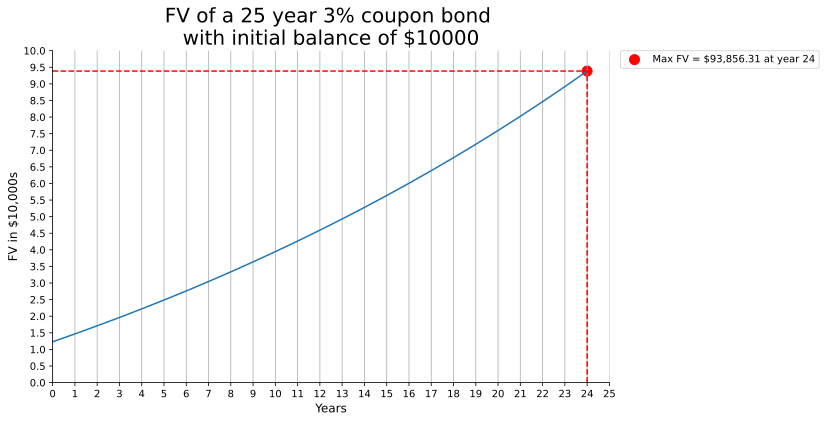

In [30]:
plt.figure(figsize=(10,6))
plt.plot(FV_initial_bal/(10**4)) 
plt.title(f"FV of a 25 year 3% coupon bond \n with initial balance of ${10000} " , 
          fontsize=20)
plt.xlabel("Years", fontsize = 12)
plt.ylabel("FV in $10,000s", fontsize = 12)


# plot the vertical line
plt.plot([FV_initial_bal.argmax(),FV_initial_bal.argmax()] , 
         [0 , FV_initial_bal[FV_initial_bal.argmax()]/(10**4)] , 
         ls = "--", 
         color = "red", 
         markersize = 10)

# plot the horizontal line
plt.plot([0,FV_initial_bal.argmax()] , 
         [FV_initial_bal[FV_initial_bal.argmax()]/(10**4) , FV_initial_bal[FV_initial_bal.argmax()]/(10**4)] , 
         ls = "--", 
         color = "red", 
         markersize = 10)

# plot the point of intersection
plt.scatter(FV_initial_bal.argmax() , 
            FV_initial_bal[FV_initial_bal.argmax()]/(10**4) , 
            s = 100, 
            color = "red", 
            marker = "o", 
            label = f"Max FV = ${FV_initial_bal[FV_initial_bal.argmax()]:,.2f} at year {FV_initial_bal.argmax()}"
            )

plt.autoscale(enable=True, axis='both', tight=True)
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)

plt.xticks(np.arange(0, 25+1, 1))
plt.yticks(np.arange(0,10+0.5,0.5))
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(axis = 'x')
plt.show()

In [31]:
PV = -10000
cf = -2000
r = 0.03
n = 25

In [32]:
FV_initial_bal = npf.fv(rate=r ,nper = n , pmt = cf , pv = PV)
FV_initial_bal

93856.30794015658

### Evaluating Annuities with npf.fv() - payout phase

In [33]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

At Retirement, you have an Annuity Contract worth 100,000 USD. Assume you get payouts of 5,000 USD p.a. (in arrears) and a fixed interest rate of 3% p.a.
What is the remaining value of your Contract after 25 years?

In [34]:
PV = 100000
cf = 5000
r = 0.03

In [35]:
cf_retirement = np.zeros(shape=25)
cf_retirement = np.insert(arr = cf_retirement, obj = 0 , values = PV)
cf_retirement

array([100000.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.])

In [36]:
for idx in range(1,len(cf_retirement)):
    cf_retirement[idx] = (cf_retirement[idx-1]*(1+r) - cf)

In [37]:
cf_retirement

array([100000.        ,  98000.        ,  95940.        ,  93818.2       ,
        91632.746     ,  89381.72838   ,  87063.1802314 ,  84675.07563834,
        82215.32790749,  79681.78774472,  77072.24137706,  74384.40861837,
        71615.94087692,  68764.41910323,  65827.35167633,  62802.17222662,
        59686.23739341,  56476.82451522,  53171.12925067,  49766.26312819,
        46259.25102204,  42647.0285527 ,  38926.43940928,  35094.23259156,
        31147.05956931,  27081.47135639])

In [38]:
cf_retirement[-1]

27081.47135638573

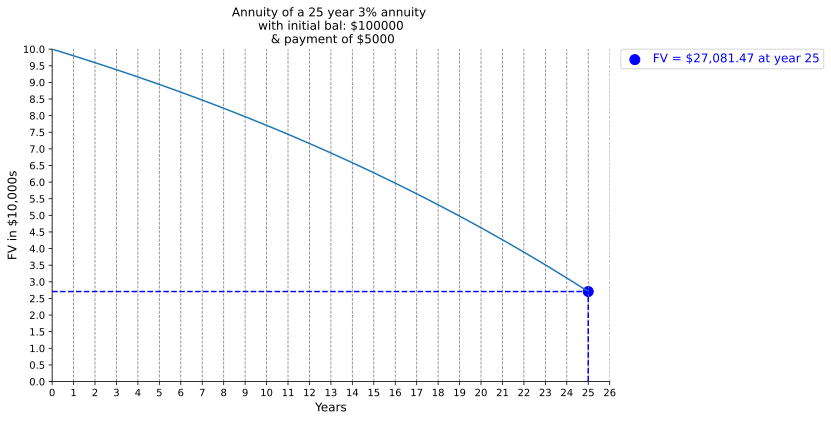

In [39]:
plt.figure(figsize=(10,6))
plt.plot(cf_retirement/(10**4)) 
plt.title(f"Annuity of a 25 year 3% annuity \n with initial bal: ${100000} \n & payment of ${5000}", 
          fontsize=12)
plt.xlabel("Years", fontsize = 12)
plt.ylabel("FV in $10,000s", fontsize = 12)


# plot the vertical line
plt.plot([cf_retirement.argmin(),cf_retirement.argmin()] , 
         [0 , cf_retirement[cf_retirement.argmin()]/(10**4)] , 
         ls = "--", 
         color = "blue", 
         markersize = 10)

# plot the horizontal line
plt.plot([0,cf_retirement.argmin()] , 
         [cf_retirement[cf_retirement.argmin()]/(10**4) , cf_retirement[cf_retirement.argmin()]/(10**4)] , 
         ls = "--", 
         color = "blue", 
         markersize = 10)

# plot the point of intersection
plt.scatter(cf_retirement.argmin() , 
            cf_retirement[cf_retirement.argmin()]/(10**4) , 
            s = 100, 
            color = "blue", 
            marker = "o", 
            label = f"FV = ${cf_retirement[cf_retirement.argmin()]:,.2f} at year {cf_retirement.argmin()}"
            )

plt.autoscale(enable=True, axis='both', tight=True)
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)

plt.xticks(np.arange(0, 26+1, 1))
plt.yticks(np.arange(0,10+0.5,0.5))

legend = ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
legend.get_texts()[0].set_fontsize(12)
legend.get_texts()[0].set_color("blue")

plt.grid(axis = 'x' , ls = "--", color = "grey")
plt.show()

In [40]:
#PV * (1 + r) - cf

In [41]:
#(PV * (1 + r) - cf) * (1 + r) - cf

#### Now, let's do it in Python with numpy-financial:
```python
import numpy_financial as npf
#FV of an annuity with an initial balance 100000, annual payment of 5000, interest rate of 3% and 25 years
fv = npf.fv(rate=0.03, nper=25, pmt=-5000, pv=+100000)  
# Remark: In npf.fv, the rule is: Cash outflows and inflows must have opposite signs.
print(f"The remaining value of the contract after 25 years is: {fv:.2f} USD")
```

In [42]:
PV = +100000
cf = -5000
r = 0.03
n = 25

In [43]:
FV = -npf.fv(rate = r, nper = n, pmt = cf, pv = PV)
FV

27081.47135638559

### Solving for annuity payments with npf.pmt() 

In [44]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

You consider to pay 25 annual installments (in arrears) into an Annuity Contract with an interest rate of 3% p.a. Calculate the annual payments to end up with a Contract Value of 100,000 USD in 25 years. 

A crash course to calculate the `(constant)annual payment A` to end up with a `contract value (FV)` in `N years` with an `interest rate of r`: <br>

$$
\begin{aligned}
\text{CashFlows} &= \left[
\begin{aligned}
& A, \\
& (1+r)A + A, \\
& (1+r)((1+r)A + A), \\
& \dots, \\
& (1+r)^{N-1}A + (1+r)^{N-2}A + \dots + A
\end{aligned}
\right]
\end{aligned}
$$


Hence, we have:
\begin{aligned}
CashFlows[m] &= A + (1+r)A + (1+r)^2A + \dots + (1+r)^{m-1}A \\
             &= A \left( \frac{1 - (1+r)^m}{1 - (1+r)} \right) \\
             &= A \left( \frac{(1+r)^m - 1}{r} \right)
\end{aligned}

Specifically, we will have the following formula for the last CashFlow in year N:
$$\text{Contract Value  (FV)} = \text{CashFlows[N]} = A \left( \frac{(1+r)^N - 1}{r} \right)$$

So, we can calculate the annual payment A with the following formula:
$$\color{lime}{A} = \frac{FV \cdot r}{(1+r)^N - 1}$$

This is exactly what npf.pmt() does for us. We can calculate the annual payment A with the following code:

```python
import numpy_financial as npf
# Calculate the annual payment A to end up with a contract value of 100,000 USD
# in 25 years with an interest rate of 3% p.a.
A = npf.pmt(rate=0.03, nper=25, pv=0, fv=100000)
print(f"The annual payment to end up with a contract value of 100,000 USD in 25 years is: {A:.2f} USD")
```



In [45]:
PV = 0
FV = 100000
n = 25
r = 0.03

In [46]:
A = -npf.pmt(rate = r, nper = n, pv = PV, fv = FV)
print(f'''The annual payment to end up with a 
contract value of 100,000 USD in 25 years is: {A:.2f} USD.
Minus (-) sign is showing the annual withdrawal.''')
print()
print(f"The contract value at the end of 25th year is {-npf.fv(rate = r, nper = n, pmt = cf, pv = 0):.2f} USD.")

The annual payment to end up with a 
contract value of 100,000 USD in 25 years is: 2742.79 USD.
Minus (-) sign is showing the annual withdrawal.

The contract value at the end of 25th year is -182296.32 USD.


### Solving for the number of periodic payments with np.nper()

In [47]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

You consider to pay N annual installments of 2,500 USD (in arrears) into an Annuity Contract with an interest rate of 3% p.a. Calculate the time / number of periods until you end up with an Contract Value of 100,000 USD. 

Crash course to calculate the number of periods N to end up with a contract value (FV) in N years with an interest rate of r and an annual payment A:
$$
\begin{aligned}
\text{CashFlows}_{0} &= \left[A \right] \\
\text{CashFlows}_{1} &= \left[(1+r)A + A \right] \\
\text{CashFlows}_{2} &= \left[(1+r)((1+r)A + A) + A \right] \\
&\dots \\
\text{CashFlows}_{N} &= \left[(1+r)^N A + (1+r)^{N-1} A + \dots + (1+r)A + A \right] \\
\end{aligned}
$$


Hence, we have:
$$
\begin{aligned}
\text{CashFlows}_{0} &= \left[A \right] \\
\text{CashFlows}_{1} &= \left[A((1+r) + 1) \right] \\
\text{CashFlows}_{2} &= \left[A((1+r)^2 + (1+r) + 1) \right] \\
&\dots \\
\text{CashFlows}_{N} &= \left[A((1+r)^N + (1+r)^{N-1} + \dots + (1+r) + 1) \right] \\
\end{aligned}
$$

So, if we simplify the last CashFlow in year N, we get:
$$\text{CashFlows}_{N} = A \left( \frac{(1+r)^{N+1} - 1}{r} \right)$$

Now, we can calculate the number of periods N with for the future contract value (FV) (CashFlows N'th) using the following formula:
$$\color{pink}{N} = \frac{\log\left( \frac{FV \cdot r}{A} + 1 \right)}{\log(1+r)} - 1$$

That's exactly what npf.nper() does for us. We can calculate the number of periods N with the following code:

```python
import numpy_financial as npf
# Calculate the number of periods N to end up with a contract value of 100,000 USD
# with an annual payment of 2,500 USD and an interest rate of 3% p.a.
N = npf.nper(rate=0.03, pmt=-2500, pv=0, fv=100000)
print(f"The number of periods to end up with a contract value of 100,000 USD is: {N:.2f} years")
```



In [48]:
PV = 0
cf = 2500
FV = 100000
r = 0.03
# n = number of years?

In [49]:
n_manual = (np.log(FV*r/cf + 1)/np.log(1+r))-1
n_manual

25.67419856600637

In [50]:
n = npf.nper(rate = r , pmt = -cf , pv = PV , fv = FV)
n

array(26.67419857)

In [51]:
cv = np.zeros(25) # contract value
cv[0] = cf
cv

array([2500.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.])

In [52]:
cv = np.zeros(25+2) # contract value
cv[0] = cf
for year in range(1,25+2):
    cv[year] = cv[year-1]*(1+r) + cf

cv

array([  2500.        ,   5075.        ,   7727.25      ,  10459.0675    ,
        13272.839525  ,  16171.02471075,  19156.15545207,  22230.84011563,
        25397.7653191 ,  28659.69827868,  32019.48922704,  35480.07390385,
        39044.47612096,  42715.81040459,  46497.28471673,  50392.20325823,
        54403.96935598,  58536.08843666,  62792.17108976,  67175.93622245,
        71691.21430912,  76341.9507384 ,  81132.20926055,  86066.17553837,
        91148.16080452,  96382.60562865, 101774.08379751])

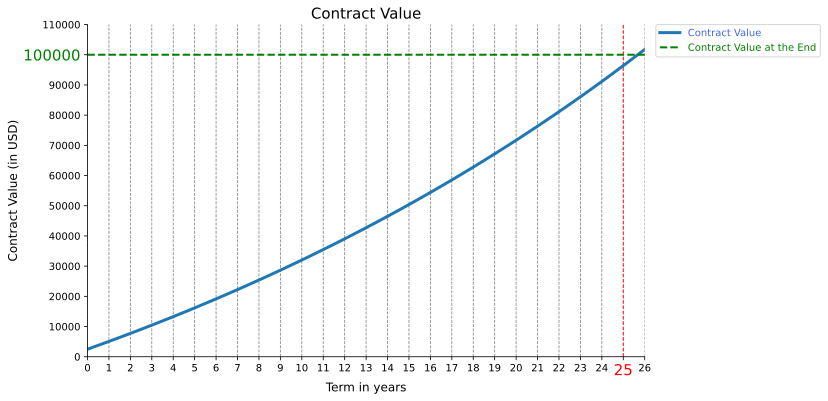

In [53]:
plt.figure(figsize = (10,6))
plt.plot(cv , lw = 3 , label = "Contract Value")
plt.title("Contract Value", fontsize = 15)
plt.xlabel("Term in years", fontsize = 12)
plt.ylabel("Contract Value (in USD)", fontsize = 12)

plt.plot()
ax = plt.gca()
ax.spines[["top","right"]].set_visible(False)
plt.autoscale(enable=True, axis='both', tight=True)

# plot the horizontal line at  $100,000 USD 
ax.hlines(y = 100000 , 
          xmin = 0 , xmax = 25+1 , 
          linestyles = "dashed", color = "green", linewidth = 2, fc = "red",
          label = "Contract Value at the End")

# Set the x-ticks and set the color and size of the 25th x-tick
x_ticks = np.arange(0, 26+1, 1)
ax.set_xticks(x_ticks)
ax.get_xticklabels()[25].set_color("red")
ax.get_xticklabels()[25].set_size(15)


# Set the y-ticks
y_ticks = np.arange(0, 100000+15000, 10000)
ax.set_yticks(y_ticks)
# Set the y-tick labels color and size for the 10th y-tick
ax.get_yticklabels()[10].set_color("green")
ax.get_yticklabels()[10].set_size(15)

# Draw ALL grid lines in grey (this is the correct method)
ax.grid(True,axis ="x" , ls = "--", color = "grey")
# Get all x-axis grid line objects
grid_lines = ax.get_xgridlines()
grid_lines[25].set_color("red")
grid_lines[25].set_linewidth(1)

# Add a legend to the plot and set the color of the legend text to green
legend = ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
legend.get_texts()[0].set_color("royalblue")
legend.get_texts()[1].set_color("green")

plt.show()

### Calculating the required Contract Value with npf.pv()

At Retirement, you have an Annuity Contract worth x USD. Assume you get payouts of 5,000 USD p.a. (in arrears) and a fixed interest rate of 3% p.a. The remaining value of your Contract after 25 years should be 20,000 USD. Calculate the required initial Contract Value (__PV__)!

A crach course to calculate the required initial contract value (PV) to end up with a remaining contract value (FV) in N years with an interest rate of r and an annual payment A:
$$
\begin{aligned}
\text{CashFlows}_{0} &= \left[PV \right] \\
\text{CashFlows}_{1} &= \left[(1+r)PV - A \right] \\
\text{CashFlows}_{2} &= \left[(1+r)((1+r)PV - A) - A \right] \\
&\dots \\
\text{CashFlows}_{N} &= \left[(1+r)^N PV - A \left( \frac{(1+r)^N - 1}{r} \right) \right] \\
\end{aligned}
$$
So, we can calculate the required `initial contract value (PV)` with the following formula:
$$\color{yellow}{PV} = \frac{FV + A \left( \frac{(1+r)^N - 1}{r} \right)}{(1+r)^N}$$
That's exactly what `npf.pv()` does for us. We can calculate the required initial contract value (PV) with the following code:

```python
import numpy_financial as npf

PV = npf.pv(rate=r, nper=N, pmt=A, fv=FV)
```

In [54]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [55]:
FV = 20000
r = 0.03
n = 25
cf = 5000

In [56]:
PV = npf.pv(rate = r, nper = n, pmt = cf, fv = FV)
PV

-96617.84984162332

Now we can double check our result with the following code:

```python
import numpy_financial as npf
# Calculate the remaining value of the contract after 25 years with the calculated PV
fv = npf.fv(rate=r, nper=N, pmt=-A, pv=PV)
print(f"The remaining value of the contract after 25 years is: {fv:.2f} USD")
```

In [57]:
npf.fv(rate = r, nper = n, pmt = cf, pv = PV)

20000.0

### Frequency of compounding and the effective annual interest rate

In [58]:
PV = 100
r = 0.03
n = 2

In [59]:
FV = PV * (1 + r)**n
FV

106.08999999999999

You have 100 USD today and you save it for two years at a __stated annual interest rate of 3%__. The Compounding frequency is __quarterly__. <br>
Calculate the Future Value (in two years) and the __effective interest rate__.

In [60]:
PV = 100
m = 4
r = 0.03
n = 2

In [61]:
FV = PV * (1 + r/m)**(n*m)
FV

106.15988478182759

We know that the formula to calculate the future value (FV) with a stated annual interest rate (r), a compounding frequency of m and a number of years (N) is:
$$FV = PV \cdot \left(1 + \frac{r}{m}\right)^{m \cdot N}$$

We define the `periodic interest rate` as the interest rate that would give us the same future value (FV) with annual compounding. 
$$
\color{orange}{r_{periodic}} = \frac{r}{m}
$$

Hence, we can calculate the effective interest rate with the following formula:

$$
\frac{FV}{PV} = \left(1 + \color{orange}{r_{periodic}}
\color{white}\right)^{m \cdot N} \\
\Rightarrow 
\color{gold}{r_{eff}} = \left( \frac{FV}{PV} \right)^{\frac{1}{N}} - 1
$$
or equivalently:

$$
\begin{aligned}

\color{gold}{r_{eff}} &= \left(1 + \color{orange}{r_{periodic}}
\color{white}\right)^m - 1 \\
 &= \left(1 + \frac{r}{m}\right)^m - 1 \\

\end{aligned}

$$

So, we can calculate the future value (FV) with the following code:
```python
import numpy_financial as npf
# Calculate the future value with a stated annual interest rate of 3%, a compounding frequency of quarterly and a number of years of 2
FV = npf.fv(rate=0.03/4, nper=4*2, pmt=0, pv=-100)
print(f"The future value of 100 USD after 2 years with quarterly compounding is: {FV:.2f} USD")
```





Let's calculate the effective interest rate with the following code:
```python
import numpy_financial as npf
# Calculate the effective interest rate with a stated annual interest rate of 3% and a compounding frequency of quarterly
r_eff = (1 + 0.03/4)**4 - 1
print(f"The effective interest rate with a stated annual interest rate of 3% and a compounding frequency of quarterly is: {r_eff:.4%}")
```

In [62]:
r_eff = (1 + r/m)**m - 1
r_eff

0.030339190664062654

We can also calculate the effective interest rate with the help of FV and PV:

In [63]:
r_eff = (FV / PV)**(1/n) - 1 
r_eff

0.030339190664062654

### Evaluating a complete Retirement Plan A-Z

Assume a 30-year-old investor wants to retire in 35 years at the age of 65. He will earn 4.0% p.a. on his Investment during the Funding Phase (already fixed) and he expects to earn 3.0% p.a. on his Investment during the Payout Phase (fixed upon retirement). How much must he deposit at the end of each month for the next 35 years in order to be able to withdraw 2,500 USD per month (at the beginning of each month) for 25 years? The Annuity Contract´s final Value shall be 100,000 USD when he is 90 years old (to cover some more years).  

__Step 1: Payout Phase__

In [64]:
import numpy as np
import numpy_financial as npf 
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

We divide the problem into two sections:

Section1: Funding Phase (30–65 years)

\begin{aligned}
n_1  &= \text{number of periods} = 35 \\
cf_1 &= \text{annual cashflow (deposit)} = ? \\
r_1  &= \text{interest rate} = 4.0\% \\
m = 12 &= \text{compounding frequency} = 12 \\
r_{eff_1} &= \text{effective interest rate} = (1 + r_1)^{1/12} - 1 = \frac{r_1}{m} = 0.3333\% \\
FV_1 &= \text{future value at retirement} = ?
\end{aligned}

Section2: Payout Phase (65–90 years)


\begin{aligned}
PV = FV_1 &= \text{initial contract value at retirement} = ? \\
n_2  &= \text{number of periods} = 25 \\
cf_2 &= \text{annual withdrawal} = 5000 \\
r_2  &= \text{interest rate} = 3.0\% \\
m = 12 &= \text{compounding frequency}\\
r_{eff_2} &= \text{effective interest rate} = (1 + r_2)^{1/12} - 1 = \frac{r_2}{m} =  0.25\% \\
FV_2 &= \text{remaining value after 25 years} = 20000 
\end{aligned}


Let's look at a contract value of 100,000 USD with a 3% interest rate and a 25 year term.

In [65]:
#PV = ?
FV2 = 100000
n2 = 25
r2 = 0.03
m = 12
cf2 = 2500 # cash outflow
r_eff2 = 0.03/12


In [66]:
PV2 = npf.pv(rate = r_eff2, nper = n2*m, pmt = cf2, fv = FV2 , when = "begin")
PV2

-575789.9978483317

So FV1 = PV2 = 575789.9978483317. Now we can calculate the required annual payment A  (cash inflow) for the funding phase (30-65 years):

In [67]:
FV1 = -PV2
FV1

575789.9978483317

In [68]:
r1 = 0.04
m = 12
PV1 = 0
#cf_inflow = ?
n1 = 35
r_eff1 = 0.04/12

In [69]:
cf_inflow = npf.pmt(rate = r_eff1, nper = n1*m, pv = PV1, fv = FV1 )
cf_inflow

-630.1526790408823

### Retirement Plan: Sensitivity Analysis

In [70]:
np.arange(0.005, 0.065, 0.005)

array([0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 , 0.045,
       0.05 , 0.055, 0.06 ])

In [71]:
m = 12
cf_2 = 2500
n_2 = 25
FV_2 = 100000
r_2 = np.arange(0.005, 0.065, 0.005)

In [72]:
PV_2 = npf.pv(rate = r_2/m, nper = n_2*m, pmt = cf_2, fv = FV_2, when = "begin")
PV_2

array([-793426.41897161, -741795.38006778, -694625.90517336,
       -651486.6280425 , -611990.48665175, -575789.99784833,
       -542573.04921771, -512059.15047025, -483996.09318006,
       -458156.9734919 , -434337.5375343 , -412353.81381446])

In [73]:
r_2[4] , PV_2[4]

(0.025, -611990.4866517518)

In [74]:
r_2[5] , PV_2[5]

(0.030000000000000002, -575789.9978483317)

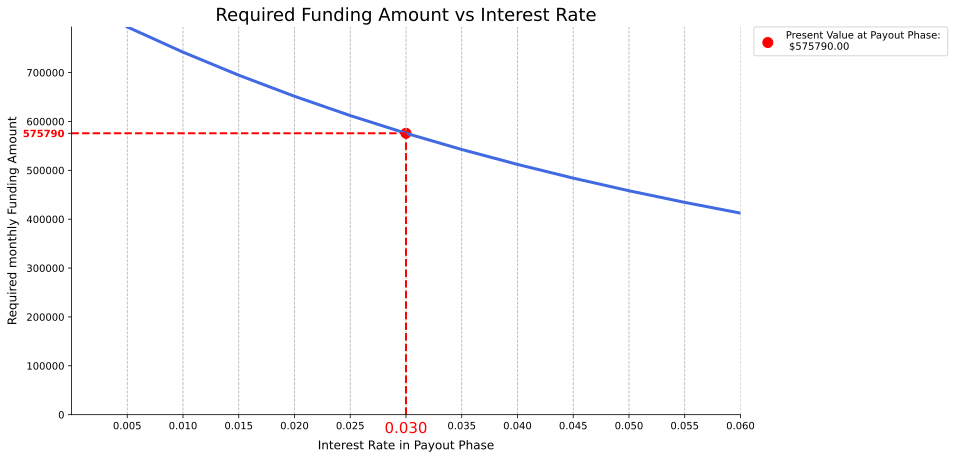

In [75]:
plt.figure(figsize = (12, 7))
plt.plot(np.arange(0.005, 0.065, 0.005), np.abs(PV_2) , color = "royalblue" , linewidth = 3)
plt.scatter(r_2[5] , -PV_2[5] , s = 100, color = "red", marker = "o", label = f"Present Value at Payout Phase: \n ${-PV_2[5]:.2f}")
plt.title("Required Funding Amount vs Interest Rate", fontsize = 18)
plt.xlabel("Interest Rate in Payout Phase", fontsize = 12)
plt.ylabel("Required monthly Funding Amount", fontsize = 12)


ax = plt.gca()

x_ticks = r_2 = np.arange(0.005, 0.065, 0.005)
ax.set_xticks(x_ticks)
ax.get_xticklabels()[5].set_color("red")
ax.get_xticklabels()[5].set_size(15)

#ax.axhline(y = -PV_2[5] , color = "red", linewidth = 2, linestyle = "dashed" , label = "Present Value at the End")
ax.plot([r_2[5], r_2[5]] , [0 ,-PV_2[5]] , color = "red" , linewidth = 2 , linestyle = "dashed" )
ax.plot([0 , r_2[5]] , [-PV_2[5],-PV_2[5]] , color = "red" , linewidth = 2 , linestyle = "dashed" )
# Add the Present Value as a y-tick
y_ticks = list(ax.get_yticks())
pv_value = -PV_2[5]  # This should be 575790.00 based on your data
y_ticks.append(pv_value)
y_ticks = sorted(y_ticks)  # Keep ticks in ascending order
ax.set_yticks(y_ticks)

# Optional: Color that specific y-tick label
ax.get_yticklabels()[y_ticks.index(pv_value)].set_color("red")
ax.get_yticklabels()[y_ticks.index(pv_value)].set_fontweight("bold")

ax.spines[["top","right"]].set_visible(False)

plt.autoscale(enable=True, axis='both', tight=True)
plt.grid(axis = "x" , linestyle = "--" )
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

### Amortizing Mortgage Loan - Debt Sizing

You consider to buy a new home for a Purchase Price of 400,000 USD. You have 150,000 USD in your savings account. Therefore, you require another 250,000 USD from a Bank (Amortizing Mortgage) to realize the Deal. Your local Bank quotes the following Mortgage terms:
- Initial Loan Amount shall not exceed 75% of Purchase Price.
- Fixed interest rate: 5.0% p.a. (compounded monthly)
- Initial Term with fixed interest rate is 30 years
- Outstanding Loan Amount after 30 Years shall not exceed 100,000 USD
- Loan payments (interest & amortization) shall be made monthly in arrears
- Monthly loan payments shall not exceed 1/3 of your current available monthly income of 4,800 USD 

Calculate the __effective annual interest rate__. <br>
__Maximize the Loan Amount__ (and minimize the funding required from your savings account)! <br>
Calculate __interest component__, __amortization component__ and __outstanding loan__ balance throughout the term and __visualize__! 

In [76]:
import numpy as np
import numpy_financial as npf 
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [77]:
m = 12 # payments must be made monthly
pp = 400000 # purchase price
max_LTV = 0.75 # maximum loan to value; loan should be <=75% of the purchase price.
r = 0.05 # fixed interest rate
available_income = 4800
DSCR = 3/1 # debt service coverage ratio 
cf = -available_income / DSCR # cash outflow: why is it negative? Because it's a loan payment.
n = 30 # loan term in years.
FV = -100000 # why is it negative? Because it's a loan.

### $\color{pink}\text{1. Calculate the effective annual interest rate with the following code:}$
```python
# Calculate the effective annual interest rate with a stated annual interest rate of 5% and a compounding frequency of monthly
r_eff = (1 + 0.05/12)**12 - 1
print(f"The effective annual interest rate is: {r_eff:.4f} or {r_eff*100:.2f}%")
```

In [78]:
r_eff = (1 + r/m)**m - 1 
r_eff

0.051161897881732976

### $\color{pink}{\text{2. Calculate the maximum loan amount with the following code:}}$
```python
# Calculate the maximum loan amount with a stated annual interest rate of 5%, a compounding frequency of monthly, a term of 30 years, a remaining loan balance of 100,000 USD and a maximum monthly payment of 1/3 of 4,800 USD
max_monthly_payment = 4800 / 3
max_loan_amount = npf.pv(rate=0.05/12, nper=30*12, pmt=-max_monthly_payment, fv=100000)
print(f"The maximum loan amount is: {max_loan_amount:.2f} USD")
```

In [79]:
cf

-1600.0

In [80]:
PV = npf.pv(rate = r/m, nper = n*m, pmt = cf, fv = FV)
print(f"The maximum loan amount is: {PV:,.2f} USD")

The maximum loan amount is: 320,433.25 USD


In [81]:
# Now, let's re-calculate the loan amount to be <=75% of the purchase price:
max_LTV * pp

300000.0

In [82]:
# so the initial loan amount is the minimum of the PV and the maximum LTV * pp
min(PV, max_LTV * pp)

300000.0

In [83]:
print(f"The Initial Loan Amount is {min(PV, max_LTV * pp):,.2f} USD!")

The Initial Loan Amount is 300,000.00 USD!


In [84]:
loan = min(PV, max_LTV * pp)

In [85]:
loan_format = f"{loan:,.2f}"
print("The Initial Loan Amount is {} USD!".format(loan_format))

The Initial Loan Amount is 300,000.00 USD!


### $ \color{pink}{\text{3. Calculate interest component, amortization component and outstanding}}$ <br> $ \color{pink}{\text{loan balance throughout the term and visualize with the following code:}}$

### Amortizing Mortgage Loan - Interest Payments and Amortization Schedule 

Calculate __interest component__, __amortization component__ and __outstanding loan__ balance throughout the term and __visualize__! 

In [86]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [87]:
m = 12 # payments must be made monthly
loan = 300000 # loan amount
r = 0.05 # fixed interest rate
cf = -1600 # cash outflow
n = 30 # loan term in years.

In [88]:
300000 * r/m # monthly interest

1250.0

In [89]:
(300000 * (1 + r/m) + cf) # loan remaining balance after the first month

299650.0

In [90]:
(300000 * (1 + r/m) + cf) * (1 + r/m) + cf # loan remaining balance after the second month

299298.5416666667

In [91]:
npf.fv(rate = r/m, nper = n*m, pmt = cf, pv = loan)
# so the final balance is -8709.477623486891 which meets the loan issuer requirements. It already asked the 
# the remaininig amount after 30 years should not exceed 100,000 USD.

-8709.477623486891

In [92]:
last_balance_after_30_years = npf.fv(rate = r/m, nper = n*m, pmt = cf, pv = loan)
last_balance_after_30_years

-8709.477623486891

In [93]:
print(f'''The final balance after 30 years is: {last_balance_after_30_years:,.2f} USD which is less than 100,000 USD! 
The loan issuer requirements are met. 
It already asked the remaininig amount after 30 years should not exceed 100,000 USD''')

The final balance after 30 years is: -8,709.48 USD which is less than 100,000 USD! 
The loan issuer requirements are met. 
It already asked the remaininig amount after 30 years should not exceed 100,000 USD


In [94]:
final_balance = npf.fv(rate = r/m, nper = n*m, pmt = cf, pv = loan)
final_balance

-8709.477623486891

It makes sense to consider all the number of months to visualize the remaining loan balance throughout the term. So, we will have 30 years * 12 months = 360 months. 

In [95]:
list(range(n*m + 1))[:10] , list(range(n*m + 1))[-10:]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [351, 352, 353, 354, 355, 356, 357, 358, 359, 360])

In [96]:
periods = np.arange(1,n*m + 1)
periods

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [97]:
rem_loan = npf.fv(rate = r/m, nper = periods, pmt = cf, pv = loan)
rem_loan # remaining monthly loan amount during the loan term of 30 years = 360 months. So the last element is the final balance.

array([-299650.        , -299298.54166667, -298945.61892361,
       -298591.22566913, -298235.35577608, -297878.00309181,
       -297519.16143803, -297158.82461069, -296796.9863799 ,
       -296433.64048982, -296068.78065852, -295702.40057793,
       -295334.49391368, -294965.05430498, -294594.07536459,
       -294221.55067861, -293847.47380643, -293471.83828063,
       -293094.6376068 , -292715.86526349, -292335.51470209,
       -291953.57934668, -291570.05259396, -291184.9278131 ,
       -290798.19834566, -290409.85750543, -290019.89857837,
       -289628.31482244, -289235.09946754, -288840.24571532,
       -288443.74673913, -288045.59568388, -287645.7856659 ,
       -287244.30977284, -286841.16106356, -286436.33256799,
       -286029.81728702, -285621.60819238, -285211.69822652,
       -284800.08030246, -284386.74730372, -283971.69208416,
       -283554.90746784, -283136.38624896, -282716.12119166,
       -282294.10502996, -281870.33046758, -281444.79017786,
       -281017.47680361,

In [98]:
rem_loan[-1] == final_balance

True

In [99]:
npf.ppmt(rate = r/m, per = 1, nper = n*m, pv = loan, fv = rem_loan[-1])
# it is called amortization:

-350.0000000000002

In [100]:
amort = npf.ppmt(rate = r/m, per = periods, nper = n*m, pv = loan, fv = final_balance)
amort

array([ -350.        ,  -351.45833333,  -352.92274306,  -354.39325448,
        -355.86989305,  -357.35268427,  -358.84165378,  -360.33682734,
        -361.83823079,  -363.34589008,  -364.85983129,  -366.38008059,
        -367.90666426,  -369.43960869,  -370.9789404 ,  -372.52468598,
        -374.07687217,  -375.63552581,  -377.20067383,  -378.77234331,
        -380.3505614 ,  -381.93535541,  -383.52675272,  -385.12478086,
        -386.72946745,  -388.34084023,  -389.95892706,  -391.58375592,
        -393.21535491,  -394.85375222,  -396.49897619,  -398.15105525,
        -399.81001798,  -401.47589306,  -403.14870928,  -404.82849557,
        -406.51528097,  -408.20909464,  -409.90996587,  -411.61792406,
        -413.33299874,  -415.05521957,  -416.78461632,  -418.52121888,
        -420.2650573 ,  -422.0161617 ,  -423.77456238,  -425.54028972,
        -427.31337426,  -429.09384665,  -430.88173768,  -432.67707825,
        -434.47989941,  -436.29023233,  -438.10810829,  -439.93355875,
      

In [101]:
npf.ipmt(rate = r/m, per = 1, nper = n*m, pv = loan, fv = final_balance)
# it gives us the first interest payment.

array(-1250.)

In [102]:
npf.ipmt(rate = r/m, per = 2, nper = n*m, pv = loan, fv = final_balance)
# it gives us the second interest payment.

array(-1248.54166667)

In [103]:
interest = npf.ipmt(rate = r/m, per = periods, nper = n*m, pv = loan, fv = final_balance)
interest

array([-1250.        , -1248.54166667, -1247.07725694, -1245.60674552,
       -1244.13010695, -1242.64731573, -1241.15834622, -1239.66317266,
       -1238.16176921, -1236.65410992, -1235.14016871, -1233.61991941,
       -1232.09333574, -1230.56039131, -1229.0210596 , -1227.47531402,
       -1225.92312783, -1224.36447419, -1222.79932617, -1221.22765669,
       -1219.6494386 , -1218.06464459, -1216.47324728, -1214.87521914,
       -1213.27053255, -1211.65915977, -1210.04107294, -1208.41624408,
       -1206.78464509, -1205.14624778, -1203.50102381, -1201.84894475,
       -1200.18998202, -1198.52410694, -1196.85129072, -1195.17150443,
       -1193.48471903, -1191.79090536, -1190.09003413, -1188.38207594,
       -1186.66700126, -1184.94478043, -1183.21538368, -1181.47878112,
       -1179.7349427 , -1177.9838383 , -1176.22543762, -1174.45971028,
       -1172.68662574, -1170.90615335, -1169.11826232, -1167.32292175,
       -1165.52010059, -1163.70976767, -1161.89189171, -1160.06644125,
      

In [104]:
amort + interest

array([-1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
       -1600., -1600., -1600., -1600., -1600., -1600., -1600., -1600.,
      

In [132]:
rem_loan

array([-299650.        , -299298.54166667, -298945.61892361,
       -298591.22566913, -298235.35577608, -297878.00309181,
       -297519.16143803, -297158.82461069, -296796.9863799 ,
       -296433.64048982, -296068.78065852, -295702.40057793,
       -295334.49391368, -294965.05430498, -294594.07536459,
       -294221.55067861, -293847.47380643, -293471.83828063,
       -293094.6376068 , -292715.86526349, -292335.51470209,
       -291953.57934668, -291570.05259396, -291184.9278131 ,
       -290798.19834566, -290409.85750543, -290019.89857837,
       -289628.31482244, -289235.09946754, -288840.24571532,
       -288443.74673913, -288045.59568388, -287645.7856659 ,
       -287244.30977284, -286841.16106356, -286436.33256799,
       -286029.81728702, -285621.60819238, -285211.69822652,
       -284800.08030246, -284386.74730372, -283971.69208416,
       -283554.90746784, -283136.38624896, -282716.12119166,
       -282294.10502996, -281870.33046758, -281444.79017786,
       -281017.47680361,

Remark:

```python
loan_amount + np.cumsum(amortization_component) = remaining_loan_balance
```

In [129]:
loan + np.cumsum(amort) 

array([299650.        , 299298.54166667, 298945.61892361, 298591.22566913,
       298235.35577608, 297878.00309181, 297519.16143803, 297158.82461069,
       296796.9863799 , 296433.64048982, 296068.78065852, 295702.40057793,
       295334.49391368, 294965.05430498, 294594.07536459, 294221.55067861,
       293847.47380643, 293471.83828063, 293094.6376068 , 292715.86526349,
       292335.51470209, 291953.57934668, 291570.05259396, 291184.9278131 ,
       290798.19834566, 290409.85750543, 290019.89857837, 289628.31482244,
       289235.09946754, 288840.24571532, 288443.74673913, 288045.59568388,
       287645.7856659 , 287244.30977284, 286841.16106356, 286436.33256799,
       286029.81728702, 285621.60819238, 285211.69822652, 284800.08030246,
       284386.74730372, 283971.69208416, 283554.90746784, 283136.38624896,
       282716.12119166, 282294.10502996, 281870.33046758, 281444.79017786,
       281017.47680361, 280588.38295695, 280157.50121927, 279724.82414102,
       279290.34424161, 2

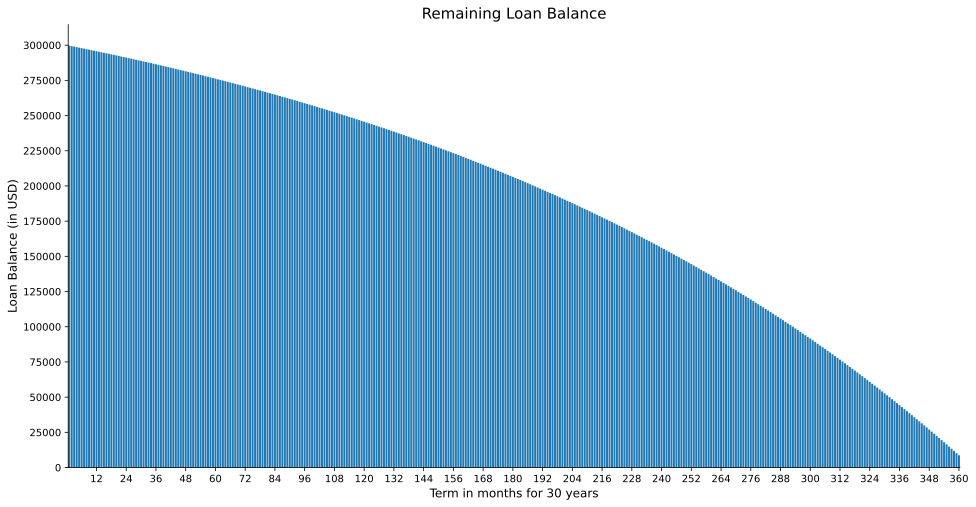

In [126]:
plt.figure(figsize = (16, 8))
plt.bar(periods, -rem_loan)
plt.title("Remaining Loan Balance", fontsize = 15)

plt.xlabel("Term in months for 30 years", fontsize = 12)
plt.xticks(np.arange(0,n*m+1 +12 , 12))

plt.ylabel("Loan Balance (in USD)", fontsize = 12)
plt.yticks(np.arange(0,300000 + 25000,25000))


ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)

plt.autoscale(enable = True , axis = "x" , tight = True)
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize = 20)
plt.show()

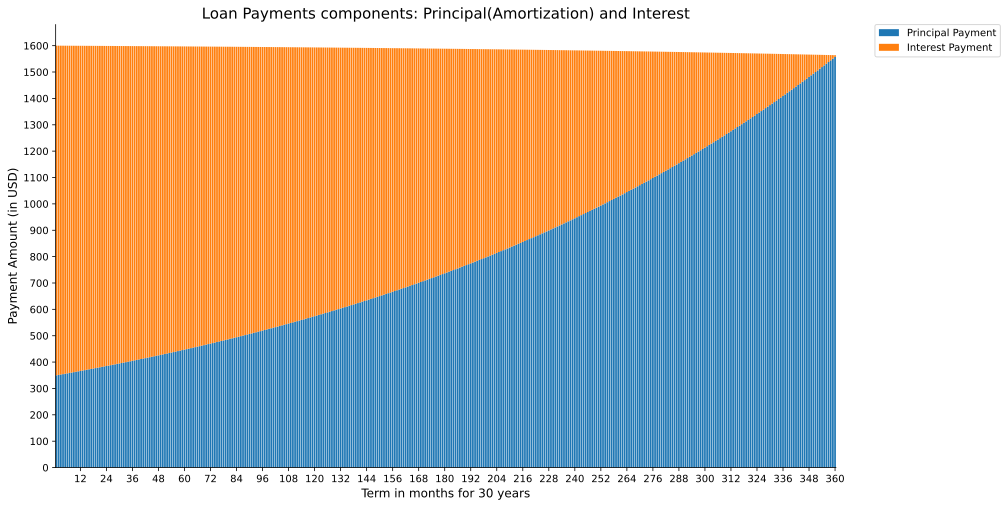

In [146]:
plt.figure(figsize = (14, 8))
plt.bar(range(1, n*m + 1), -amort, label = "Principal Payment")
plt.bar(range(1, n*m + 1), -interest, bottom = -amort, label = "Interest Payment")

plt.title("Loan Payments components: Principal(Amortization) and Interest", fontsize = 15)

plt.xlabel("Term in months for 30 years", fontsize = 12)
plt.xticks(np.arange(0,n*m+1 +12 , 12))

plt.ylabel("Payment Amount (in USD)", fontsize = 12)
plt.yticks(np.arange(0,1600+100,100))

ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)

plt.autoscale(enable = True , axis = "x" , tight = True)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_14700\3087032655.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f"{tick*100:.0f}%" for tick in yticks])


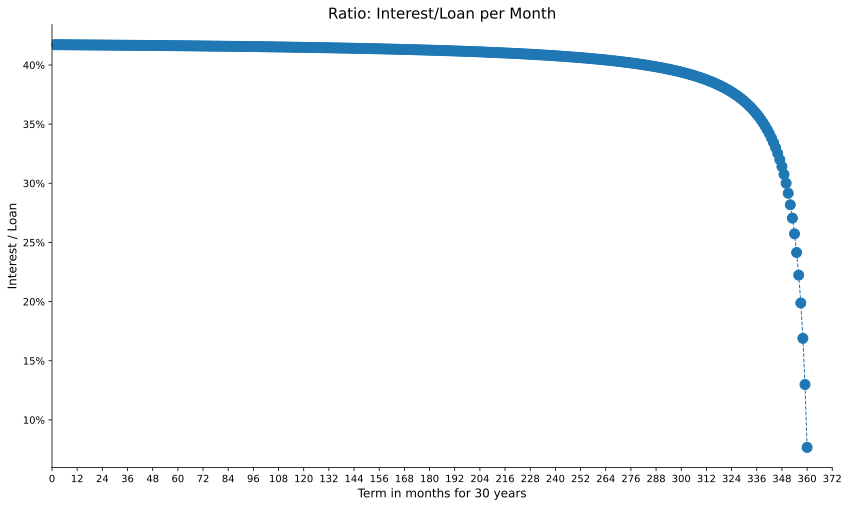

In [ ]:
plt.figure(figsize = (14, 8))

plt.plot(range(1, n*m + 1) , (interest/rem_loan)*100 ,linewidth = 1 , linestyle = "--", marker = "o", markersize = 10)

plt.title("Ratio: Interest/Loan per Month", fontsize = 15)
plt.xlabel("Term in months for 30 years", fontsize = 12)
plt.xticks(np.arange(0,n*m+1 +12 , 12))

plt.ylabel("Interest / Loan", fontsize = 12)
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim([0, n*m + 12])
#ax.set_ylim([0, 0.5])

yticks = ax.get_yticks()
ax.set_yticklabels([f"{tick*100:.0f}%" for tick in yticks])

plt.show()

###  Valuation of Bonds

You consider to purchase a Corporate Bond from XYZ Company that pays coupons of 5% p.a. (quarterly in arrears) for the next 6 years and a final repayment at maturity in 6 years. <br>
What price are you willing to pay (per 100 USD par value) if bonds with similar risk and maturity have a YTM of 4.5% p.a.?

In [5]:
import numpy as np
import numpy_financial as npf 
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [ ]:
m = 4 # quarterly coupons payments
coup_rate = 5 / m
ytm = 0.045 # bond's rate of return.
n = 6 # years
FV = 100

In [8]:
PV = npf.pv(rate = ytm/m, nper = n*m, pmt = coup_rate, fv = FV)
PV

np.float64(-102.6163208657496)

### Capital Budgeting - Mutually exclusive Projects (Part 1)

Company XYZ evaluates two mutually exclusive Investment Projects (A and B) that lead to the following (estimated) increases in company cashflows/profits (in MUSD):

- Project A: [20, 30, 40, 50, 100, 200]
- Project B: [50, 75, 100, 75, 50, 10]

Both projects require an initial Investment of 200 Million USD (to buy Machinery and Plant).

The projects are mutually exclusive. Which project should XYZ realize? Assume a company-wide required rate of return of 6.0% p.a. for comparable projects. 

Calculate the (hypothetical) required rate of return where your decision would change (crossover rate). Visualize!


In [2]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [6]:
cf_A =  [-200, 20, 30, 40, 50, 100, 200]

In [7]:
cf_B = [-200, 50, 75, 100, 75, 50, 10]

In [8]:
len(cf_A) , len(cf_B)

(7, 7)

In [5]:
r = 0.06

In [9]:
x_axis = np.arange(7)
x_axis

array([0, 1, 2, 3, 4, 5, 6])

In [10]:
cum_A = np.cumsum(cf_A)
cum_A

array([-200, -180, -150, -110,  -60,   40,  240])

In [11]:
cum_B = np.cumsum(cf_B)
cum_B

array([-200, -150,  -75,   25,  100,  150,  160])

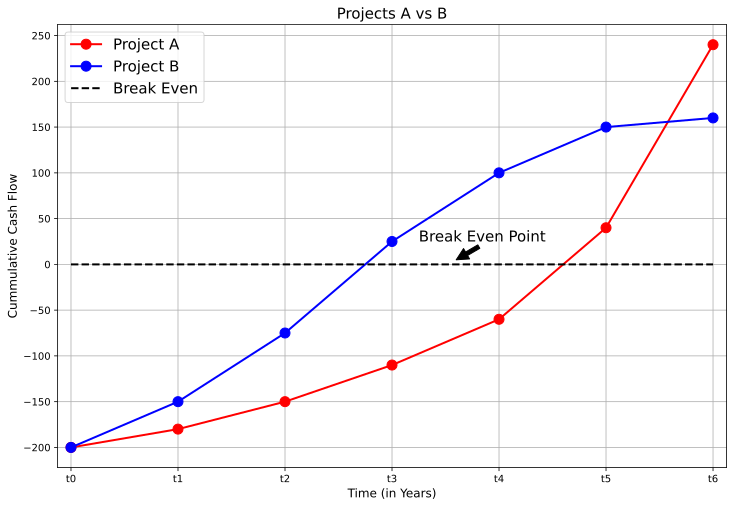

In [32]:
plt.figure(figsize = (12, 8))

plt.plot(x_axis, cum_A, color = "red", linewidth = 2, linestyle = "-", marker = "o", markersize = 10, label = "Project A")
plt.plot(x_axis, cum_B, color = "blue", linewidth = 2, linestyle = "-", marker = "o", markersize = 10, label = "Project B")
plt.hlines(y = 0, xmin = x_axis[0], xmax = x_axis[-1], linestyles= "dashed", color = "black", label = "Break Even" , linewidth = 2)

plt.title("Projects A vs B", fontsize = 15)
plt.xlabel("Time (in Years)", fontsize = 12)
plt.ylabel("Cummulative Cash Flow", fontsize = 12)

plt.yticks(range(-200,251,50))
plt.xticks(x_axis, labels = ["t0", "t1", "t2", "t3", "t4", "t5", "t6"])

plt.xlim((-0.125,6.125))

plt.annotate("Break Even Point", xy = (3.6, 5),xytext = (3.25, 25), arrowprops= {"color":"black"}, fontsize = 15)
plt.legend(loc = "best", fontsize = 15)

plt.grid()
plt.show()

### Capital Budgeting - Mutually exclusive Projects (Part 2)

In [33]:
irr_A = npf.irr(cf_A)
irr_A

0.18861794355562722

In [34]:
irr_B = npf.irr(cf_B)
irr_B

0.22406954854394745

In [35]:
npv_A = npf.npv(rate = 0.06, values = cf_A)
npv_A

134.4751975864632

In [36]:
npv_B = npf.npv(rate = 0.06, values = cf_B)
npv_B

101.70101141560401

In [41]:
# interest rate from 0% to 25%
rs = np.linspace(start = 0, stop = 0.25, num = 1000)
rs

array([0.        , 0.00025025, 0.0005005 , 0.00075075, 0.001001  ,
       0.00125125, 0.0015015 , 0.00175175, 0.002002  , 0.00225225,
       0.0025025 , 0.00275275, 0.003003  , 0.00325325, 0.0035035 ,
       0.00375375, 0.004004  , 0.00425425, 0.0045045 , 0.00475475,
       0.00500501, 0.00525526, 0.00550551, 0.00575576, 0.00600601,
       0.00625626, 0.00650651, 0.00675676, 0.00700701, 0.00725726,
       0.00750751, 0.00775776, 0.00800801, 0.00825826, 0.00850851,
       0.00875876, 0.00900901, 0.00925926, 0.00950951, 0.00975976,
       0.01001001, 0.01026026, 0.01051051, 0.01076076, 0.01101101,
       0.01126126, 0.01151151, 0.01176176, 0.01201201, 0.01226226,
       0.01251251, 0.01276276, 0.01301301, 0.01326326, 0.01351351,
       0.01376376, 0.01401401, 0.01426426, 0.01451451, 0.01476476,
       0.01501502, 0.01526527, 0.01551552, 0.01576577, 0.01601602,
       0.01626627, 0.01651652, 0.01676677, 0.01701702, 0.01726727,
       0.01751752, 0.01776777, 0.01801802, 0.01826827, 0.01851

In [42]:
# let's calculate the NPV of the project A  for each interest rate:
list_A = []
for i in rs:
    list_A.append(npf.npv(i, cf_A))
list_A

[240.0,
 239.47488441507772,
 238.95058769494227,
 238.42710831741024,
 237.90444476354853,
 237.38259551767064,
 236.86155906732526,
 236.34133390329015,
 235.82191851956568,
 235.30331141336373,
 234.78551108510376,
 234.26851603840205,
 233.7523247800651,
 233.2369358200836,
 232.72234767162152,
 232.208558851012,
 231.69556787774678,
 231.18337327446986,
 230.67197356697153,
 230.16136728417726,
 229.65155295814412,
 229.1425291240501,
 228.63429432018788,
 228.12684708795868,
 227.6201859718619,
 227.1143095194913,
 226.60921628152397,
 226.10490481171493,
 225.60137366689094,
 225.09862140693963,
 224.59664659480643,
 224.09544779648354,
 223.59502358100437,
 223.09537252043754,
 222.59649318987624,
 222.09838416743514,
 221.60104403423946,
 221.10447137441963,
 220.6086647751051,
 220.11362282641426,
 219.61934412145084,
 219.12582725629363,
 218.6330708299909,
 218.14107344455448,
 217.64983370494966,
 217.15935021909172,
 216.66962159783586,
 216.18064645497137,
 215.692423407

In [43]:
# let's calculate the NPV of the project B  for each interest rate:
list_B = []
for i in rs:
    list_B.append(npf.npv(i, cf_B))
list_B

[160.0,
 159.7223840275018,
 159.44509134253056,
 159.16812146119483,
 158.8914739004748,
 158.61514817822237,
 158.33914381315776,
 158.06346032486834,
 157.78809723380775,
 157.5130540612918,
 157.23833032949935,
 156.96392556146836,
 156.68983928109486,
 156.41607101313213,
 156.14262028318674,
 155.86948661771922,
 155.5966695440403,
 155.32416859031,
 155.05198328553624,
 154.78011315957193,
 154.5085577431146,
 154.23731656770346,
 153.96638916571786,
 153.69577507037658,
 153.4254738157344,
 153.1554849366821,
 152.8858079689431,
 152.6164424490727,
 152.3473879144566,
 152.07864390330792,
 151.81020995466704,
 151.54208560839862,
 151.2742704051901,
 151.00676388655128,
 150.7395655948103,
 150.47267507311435,
 150.20609186542626,
 149.93981551652308,
 149.67384557199566,
 149.40818157824495,
 149.14282308248232,
 148.87776963272628,
 148.61302077780138,
 148.34857606733738,
 148.08443505176578,
 147.8205972823203,
 147.55706231103323,
 147.29382969073473,
 147.03089897505185,


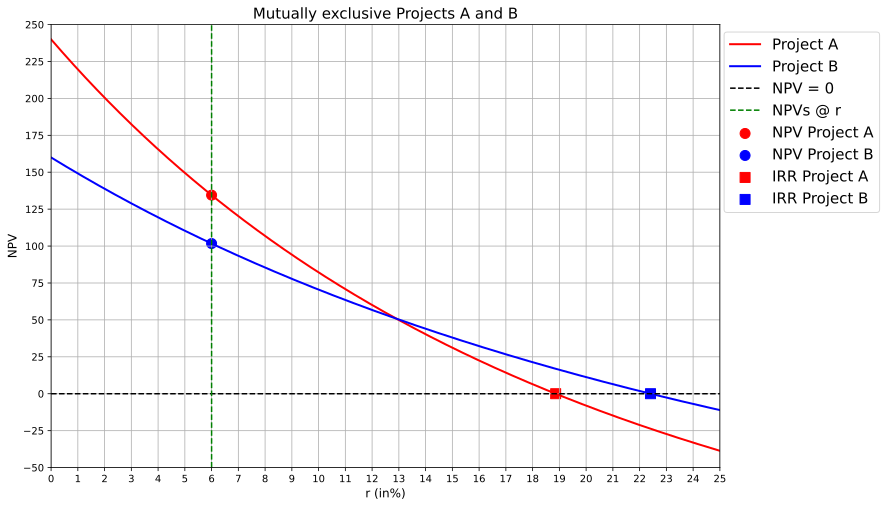

In [53]:
plt.figure(figsize = (12, 8))
plt.plot(rs, list_A, color = "red", linewidth = 2, linestyle = "-", label = "Project A")
plt.plot(rs, list_B, color = "blue", linewidth = 2, linestyle = "-", label = "Project B")

plt.hlines(y = 0, xmin = rs[0], xmax = rs[-1], linestyles= "dashed", color = "black", label = "NPV = 0")
plt.vlines(x = r, ymin = -50, ymax = 250, linestyles= "dashed", color = "green", label = "NPVs @ r")

plt.scatter(r, npv_A, s = 100, c = "red", marker = "o", label = "NPV Project A")
plt.scatter(r, npv_B, s = 100, c = "blue", marker = "o", label = "NPV Project B")
plt.scatter(irr_A, 0, s = 100, c = "red", marker = "s", label = "IRR Project A")
plt.scatter(irr_B, 0, s = 100, c = "blue", marker = "s", label = "IRR Project B")
#plt.scatter(cr, npvB, s = 400, c = "m", marker = "*", label = "Crossover Rate")

plt.xticks(np.arange(26)/100, labels = np.arange(26))
plt.yticks(np.arange(-50, 251, 25))

plt.title("Mutually exclusive Projects A and B", fontsize = 15)

plt.xlabel("r (in%)", fontsize = 12)
plt.ylabel("NPV", fontsize = 12)

plt.xlim((0, 0.25))
plt.ylim((-50, 250))

plt.legend(bbox_to_anchor = (1.25, 1), fontsize = 15)
plt.grid()
plt.show()

### Capital Budgeting - Mutually exclusive Projects (Part 3)

In [69]:
cr = 0.00 # crossover rate
step = 0.000001 # step
tolerance = 0.001 # tolerance

while True:
    npvA = npf.npv(cr , cf_A) 
    npvB = npf.npv(cr , cf_B)
    
    diff = npvA - npvB
    
    if abs(diff) > tolerance:
        if diff > 0:
            cr += step

    else:
        break

print(f"end = {cr}, \ndiff = {diff}, \nnpvA = {npvA}, \nnpvB = {npvB}")

end = 0.12913200000010847, 
diff = 0.0006877965190170698, 
npvA = 50.782160361595935, 
npvB = 50.78147256507692


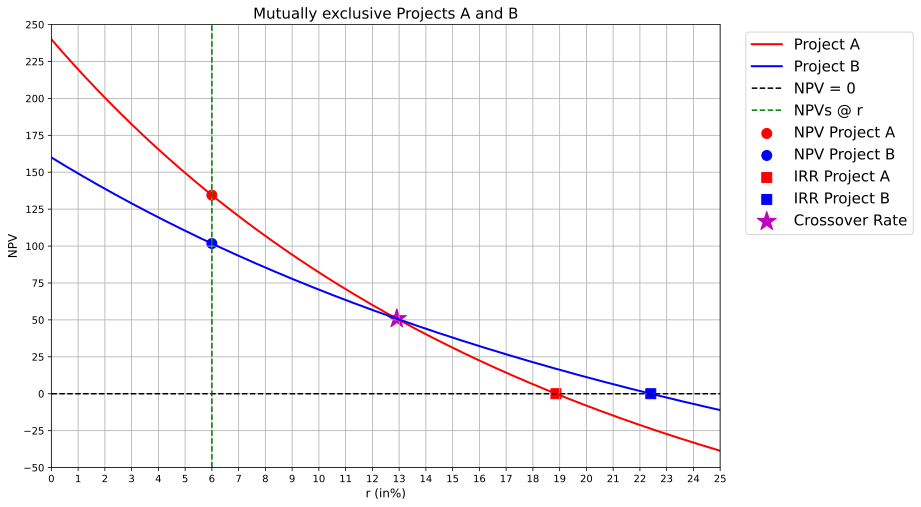

In [68]:
plt.figure(figsize = (12, 8))
plt.plot(rs, list_A, color = "red", linewidth = 2, linestyle = "-", label = "Project A")
plt.plot(rs, list_B, color = "blue", linewidth = 2, linestyle = "-", label = "Project B")

plt.hlines(y = 0, xmin = rs[0], xmax = rs[-1], linestyles= "dashed", color = "black", label = "NPV = 0")
plt.vlines(x = r, ymin = -50, ymax = 250, linestyles= "dashed", color = "green", label = "NPVs @ r")

plt.scatter(r, npv_A, s = 100, c = "red", marker = "o", label = "NPV Project A")
plt.scatter(r, npv_B, s = 100, c = "blue", marker = "o", label = "NPV Project B")
plt.scatter(irr_A, 0, s = 100, c = "red", marker = "s", label = "IRR Project A")
plt.scatter(irr_B, 0, s = 100, c = "blue", marker = "s", label = "IRR Project B")
plt.scatter(cr, npvB, s = 400, c = "m", marker = "*", label = "Crossover Rate")

plt.xticks(np.arange(26)/100, labels = np.arange(26))
plt.yticks(np.arange(-50, 251, 25))

plt.title("Mutually exclusive Projects A and B", fontsize = 15)

plt.xlabel("r (in%)", fontsize = 12)
plt.ylabel("NPV", fontsize = 12)

plt.xlim((0, 0.25))
plt.ylim((-50, 250))

plt.legend(bbox_to_anchor = (1.3, 1), fontsize = 15)
plt.grid()
plt.show()

$\color{gold}{\Large\text{Conclusion}}$: <br>
As long as the required rate of return is below the crossover rate, we should choose Project A. If the required rate of return is above the crossover rate, we should choose Project B.
<br>

$\color{hotpink}{\Large\text{Second solution}}$
<br>

is smarter than the first one, because we do not have to calculate the NPV of both projects for different required rates of return. We can directly calculate the crossover rate with the following code:

```python
import numpy as np
# Cashflows of Project A and B
cashflows_A = np.array([20, 30, 40, 50, 100, 200])
cashflows_B = np.array([50, 75, 100, 75, 50, 10])
# Calculate the difference in cashflows between Project A and B
cashflow_diff = cashflows_A - cashflows_B
# Calculate the crossover rate (IRR of the cashflow difference)
crossover_rate = npf.irr(cashflow_diff)
print(f"The crossover rate is: {crossover_rate:.4%}")
```

In [70]:
diff_cf = np.array(cf_A) - np.array(cf_B)
diff_cf

array([  0, -30, -45, -60, -25,  50, 190])

In [72]:
cr = npf.irr(diff_cf) # so the cross over rate is the the irr of the difference of the cashflows
cr

0.12913392906856225